In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hojjatk/mnist-dataset/train-images.idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels.idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images.idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels.idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte
/kaggle/input/datasets/hojjatk/mnist-dataset/train-images-idx3-ubyte/train-images-idx3-ubyte


In [6]:
import struct
def read_mnist_images(filepath):
    with open(filepath, 'rb') as f:
        # Read 16-byte header: magic number (4B), number of images (4B), rows (4B), cols (4B)
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        # Read the rest of the image data as unsigned 8-bit integers
        images = np.fromfile(f, dtype=np.uint8)
        # Reshape array to (num_images, 28, 28)
        return images.reshape(num_images, rows, cols)

def read_mnist_labels(filepath):
    with open(filepath, 'rb') as f:
        # Read 8-byte header: magic number (4B), number of items (4B)
        magic, num_items = struct.unpack(">II", f.read(8))
        # Read the label values
        labels = np.fromfile(f, dtype=np.uint8)
        return labels

# Usage with your Kaggle file paths
train_images = read_mnist_images('/kaggle/input/datasets/hojjatk/mnist-dataset/train-images-idx3-ubyte/train-images-idx3-ubyte')
train_labels = read_mnist_labels('/kaggle/input/datasets/hojjatk/mnist-dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte')

test_images = read_mnist_images('/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels = read_mnist_labels('/kaggle/input/datasets/hojjatk/mnist-dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

print(f"Train images shape: {train_images.shape}")  
print(f"Train labels shape: {train_labels.shape}") 

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)


In [9]:
import matplotlib.pyplot as plt

In [12]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

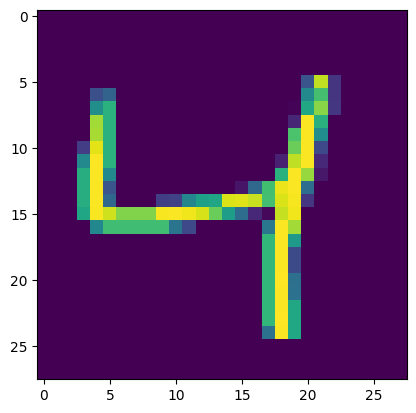

In [14]:
plt.imshow(train_images[2])

In [15]:
X_train_scaled = train_images / 255
X_test_scaled = test_images / 255

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense , Flatten

In [18]:
model = Sequential()

In [34]:
model.add(Flatten(input_shape = (28,28)))
model.add(Dense(128 , activation = 'relu'))
model.add(Dense(32 , activation = 'relu'))
model.add(Dense(10 , activation = 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 311,178 (1.19 MB)

 Trainable params: 107,636 (420.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

In [36]:
model.compile(loss= 'sparse_categorical_crossentropy' , optimizer = 'Adam' , metrics = ['accuracy'])

In [37]:
history = model.fit(X_train_scaled, train_labels , epochs = 25 , validation_split = 0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9895 - loss: 0.1264 - val_accuracy: 0.9761 - val_loss: 0.1760
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9975 - loss: 0.0154 - val_accuracy: 0.9755 - val_loss: 0.1922
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9978 - loss: 0.0145 - val_accuracy: 0.9728 - val_loss: 0.2009
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9968 - loss: 0.0187 - val_accuracy: 0.9755 - val_loss: 0.1882
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9980 - loss: 0.0138 - val_accuracy: 0.9763 - val_loss: 0.1828
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9974 - loss: 0.0161 - val_accuracy: 0.9745 - val_loss: 0.1787
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9973 - loss: 0.0164 - val_accuracy: 0.9749 - val_loss: 0.1805
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9970 - loss: 0.0180 - 

In [38]:
y_prob = model.predict(X_test_scaled)

y_pred = y_prob.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [39]:
from sklearn.metrics import accuracy_score

In [40]:
accuracy_score(test_labels , y_pred)

0.9783

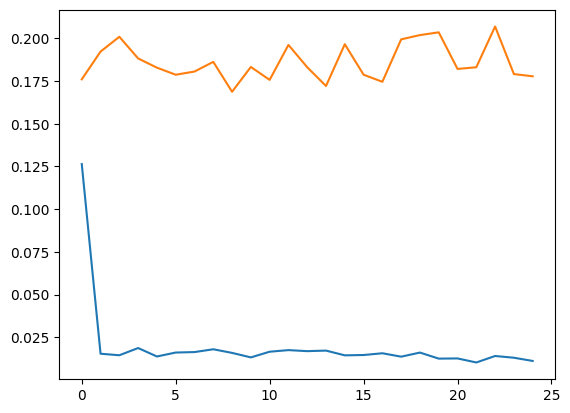

In [43]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

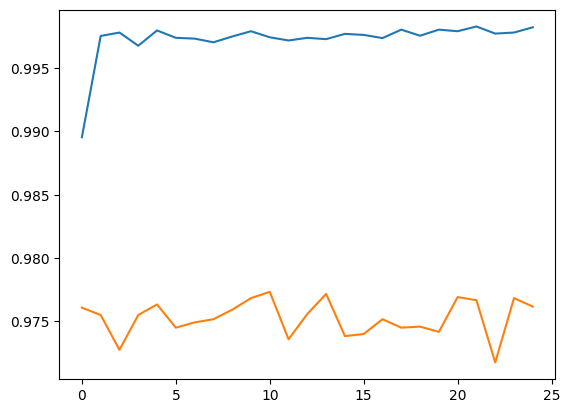

In [44]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

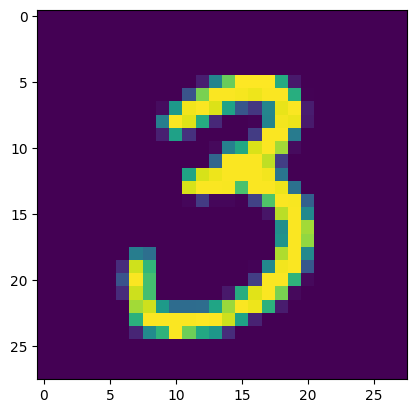

In [54]:
plt.imshow(test_images[90])

In [50]:
X_test_scaled.shape

(10000, 28, 28)

In [55]:
model.predict(X_test_scaled[90].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([3])